In [1]:
import numpy as np
from astropy.io import fits
import astropy.units as u
from importlib import reload

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Circle
from matplotlib.animation import FFMpegWriter, PillowWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['image.origin']='lower'
plt.rcParams['animation.html'] = 'html5'
plt.rcParams.update({'image.origin': 'lower',
                     'image.interpolation':'nearest'})

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics

dm_flat = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_flat.fits')
dh_command = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_dh_command_1e-9.fits')

def create_ones_array(size, up_to_index):
  """
  Creates a NumPy array of a specified size, 
  with ones up to a given index and zeros afterward.

  Args:
    size: The total size of the array.
    up_to_index: The index up to which the array should contain ones.

  Returns:
    A NumPy array with ones up to the specified index and zeros afterward.
  """
  arr = np.zeros(size)
  arr[:up_to_index] = 1
  return arr



/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-03-25 18:29:56,135	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
beamwalk_data = utils.load_pickle(esc_fresnel.path/'data/esc_beamwalk_with_m4.pkl')
# beamwalk_data = utils.load_pickle(esc_fresnel.path/'data/esc_beamwalk_with_m4_2.pkl')


0.9945635426173148
1


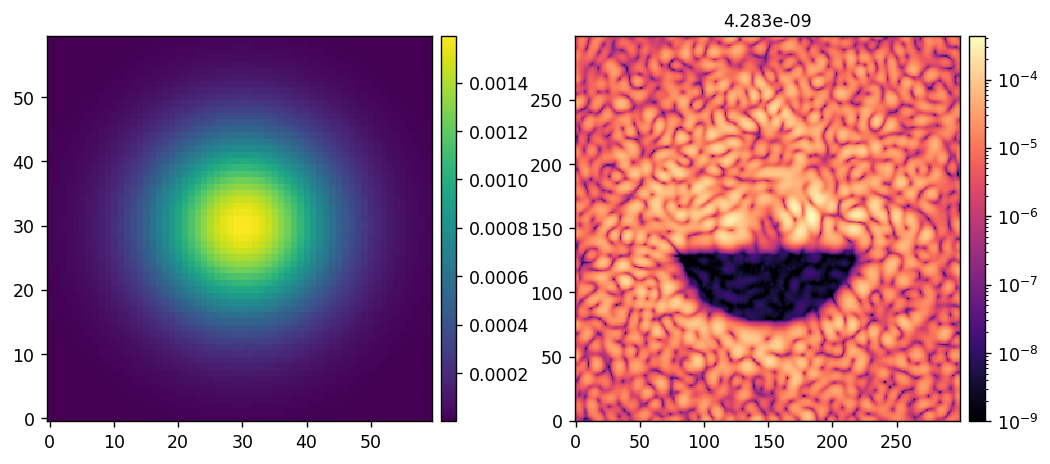

In [3]:
nominal_im = ensure_np_array(beamwalk_data['nominal_im'])
nominal_contrast = float(beamwalk_data['nominal_contrast'])
beamwalk_ims = ensure_np_array(beamwalk_data['all_images'])
contrasts = ensure_np_array(beamwalk_data['contrasts'])
pointing_pdf = ensure_np_array(beamwalk_data['pointing_pdf'])
pointing_sampling = beamwalk_data['pointing_sampling']
pointing_samples = ensure_np_array(beamwalk_data['pointing_samples'])
coro_mask = ensure_np_array(beamwalk_data['coro_mask'])

i = 3600
current_pdf_status = pointing_pdf * create_ones_array(3600, i+1).reshape(60,60) 
print(current_pdf_status.sum())
total_im = xp.sum(beamwalk_ims[:i+1] * pointing_pdf.ravel()[:i+1, None, None], axis=0) / current_pdf_status.sum()
total_contrast = np.mean( total_im[coro_mask] )
# print(total_contrast)
imshow(
    [current_pdf_status,  total_im],
    norms=[None, LogNorm(1e-9)],
    titles=[None, f'{total_contrast:.3e}'],
    cmaps=[None, 'magma'],
)

1


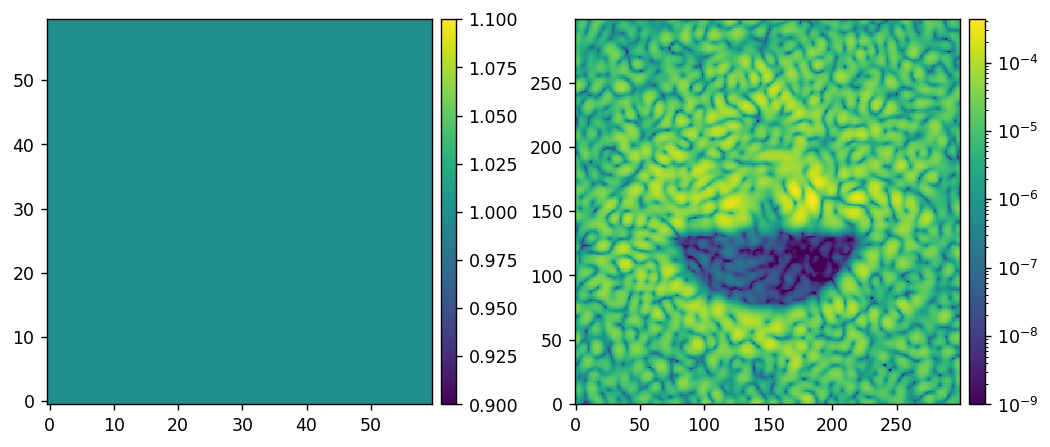

In [30]:
i = 3601
imshow(
    [create_ones_array(3600, i+1).reshape(60,60), beamwalk_ims[:i+1][-1]],
    norms=[None, LogNorm(1e-9)]
)

In [31]:
def create_anim(
        beamwalk_data,
        numframes=None, 
        cmaps=['magma', 'viridis', 'magma', 'magma'],
        norms=[None]*4,
        extents=[None]*4,
        title_fs=14,
        suptitle_fs=20,
        interval=0.01, # in seconds
        wspace=None,
        hspace=None,
        figsize=(20,8),
        dpi=125,
    ):
    numframes = beamwalk_data['all_images'].shape[0] if numframes is None else numframes
    print(numframes)

    jitter = beamwalk_data['jitter_std'].to_value(u.mas)
    m4_fsm_ratio = beamwalk_data['m4_fsm_ratio']

    nominal_im = ensure_np_array(beamwalk_data['nominal_im'])
    nominal_contrast = float(beamwalk_data['nominal_contrast'])
    beamwalk_ims = ensure_np_array(beamwalk_data['all_images'])
    contrasts = ensure_np_array(beamwalk_data['contrasts'])
    pointing_pdf = ensure_np_array(beamwalk_data['pointing_pdf'])
    pointing_sampling = beamwalk_data['pointing_sampling']
    pointing_samples = ensure_np_array(beamwalk_data['pointing_samples'])
    coro_mask = ensure_np_array(beamwalk_data['coro_mask'])

    i = 0

    im_with_beamwalk = beamwalk_ims[i]
    contrast_with_beamwalk = contrasts[i]
    pointing_offset = pointing_samples[i].to_value(u.mas)
    current_pdf_status = pointing_pdf * create_ones_array(3600, i+1).reshape(60,60) 
    total_beamwalk_im = xp.sum(beamwalk_ims[:i+1] * pointing_pdf.ravel()[:i+1, None, None], axis=0)
    total_contrast = np.mean( total_beamwalk_im[coro_mask] )

    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=figsize, dpi=dpi)
    fig.suptitle(f'Jitter = {jitter:.1f} mas, M4-FSM Correction Ratio = {m4_fsm_ratio:.2f}', fontsize=suptitle_fs)

    ax = axs[0]
    im1 = ax.imshow(nominal_im, norm=norms[0], cmap=cmaps[0], extent=extents[0])
    im1_title = ax.set_title(f'Nominal Dark Hole Image\nContrast = {nominal_contrast:.2e}', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im1, cax=cax)

    ax = axs[1]
    im2 = ax.imshow(current_pdf_status, norm=norms[1], cmap=cmaps[1], extent=extents[1])
    im2_title = ax.set_title(f'Pointing PDF\nOffset = ( {pointing_offset[0]:.1f} mas, {pointing_offset[1]:.1f} mas )', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im2, cax=cax)

    ax = axs[2]
    im3 = ax.imshow(im_with_beamwalk, norm=norms[2], cmap=cmaps[2], extent=extents[2])
    im3_title = ax.set_title(f'Instantaneous Image with Beamwalk\nContrast = {contrast_with_beamwalk:.2e}', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im3, cax=cax)

    ax = axs[3]
    im4 = ax.imshow(total_beamwalk_im, norm=norms[3], cmap=cmaps[3], extent=extents[3])
    im4_title = ax.set_title(f'Accumulated Image with Beamwalk\nContrast = {total_contrast:.2e}', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im4, cax=cax)

    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    def animate(i):

        im_with_beamwalk = beamwalk_ims[i]
        contrast_with_beamwalk = contrasts[i]
        pointing_offset = pointing_samples[i].to_value(u.mas)
        current_pdf_status = pointing_pdf * create_ones_array(3600, i+1).reshape(60,60) 
        total_beamwalk_im = xp.sum(beamwalk_ims[:i+1] * pointing_pdf.ravel()[:i+1, None, None], axis=0) / current_pdf_status.sum()
        total_contrast = np.mean( total_beamwalk_im[coro_mask] )

        # im3_title.set_text(f'CAMSCI Image: {contrast:.2e}',)

        # im1.set_data(camlo_im)
        im2.set_data(current_pdf_status)
        im3.set_data(im_with_beamwalk)
        im4.set_data(total_beamwalk_im)

        im2_title.set_text(f'Pointing PDF\nOffset = ({pointing_offset[0]:.1f}, {pointing_offset[1]:.1f}) mas')
        im3_title.set_text(f'Instantaneous Image with Beamwalk\nContrast = {contrast_with_beamwalk:.2e}')
        im4_title.set_text(f'Accumulated Image with Beamwalk\nContrast = {total_contrast:.2e}')

        # patches = axs[1].patches()
        [p.remove() for p in reversed(axs[1].patches)]
        pointing_circle = Circle((pointing_offset[0], pointing_offset[1]), 2, fill=False, color='red')
        axs[1].add_patch(pointing_circle)
        # im1.set_clim([np.min(camlo_im), np.max(camlo_im)])
        # im2.set_clim([np.min(diff_im), np.max(diff_im)])
        # im6.set_clim([np.min(lo_command), np.max(lo_command)])
        # im3.set_clim([np.min(del_command), np.max(del_command)])
        
    anim = matplotlib.animation.FuncAnimation(fig, animate, frames=numframes, interval=interval*1000) # wants interval in ms
    return anim

In [37]:
3600 * 0.01

36.0

3600


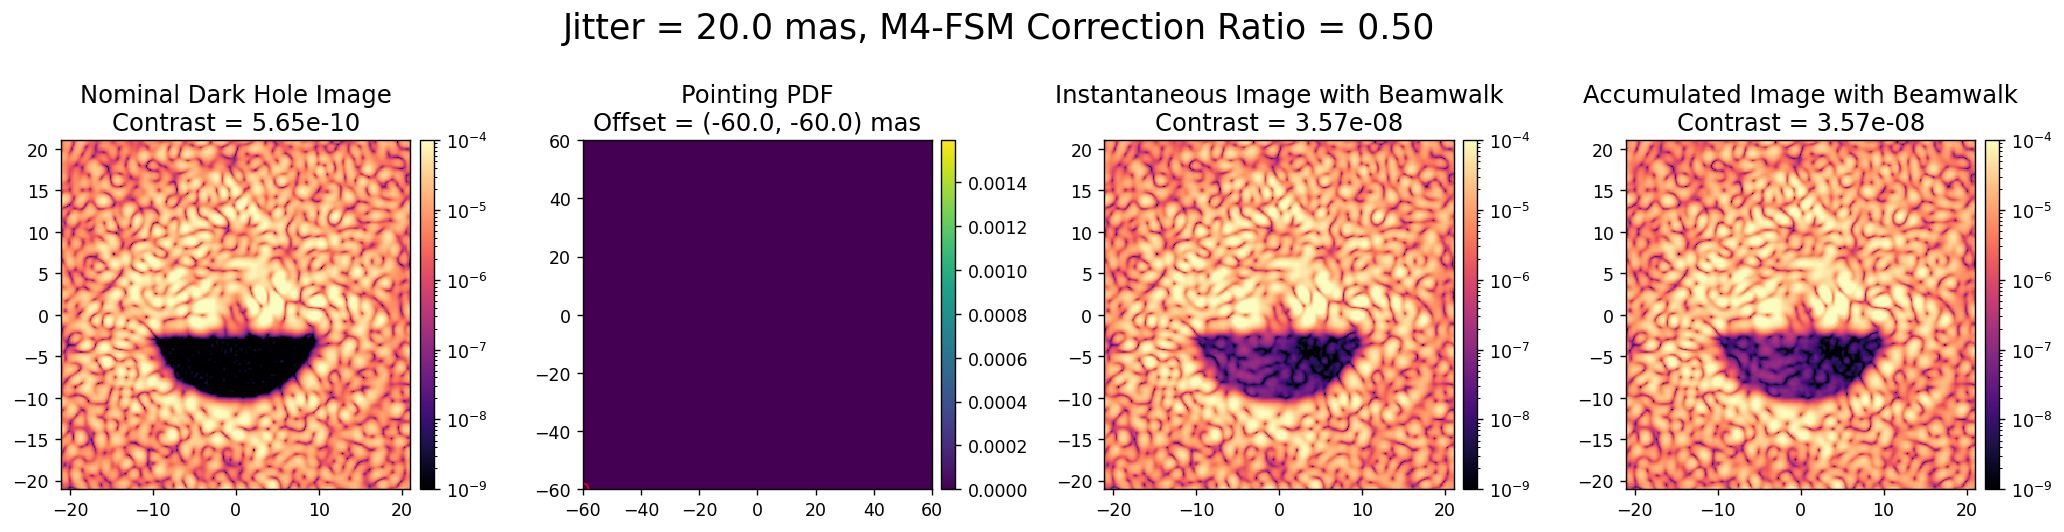

In [34]:

norms = [LogNorm(1e-9, 1e-4), Normalize(0, float(np.max(beamwalk_data['pointing_pdf']))), LogNorm(1e-9, 1e-4), LogNorm(1e-9, 1e-4)]

Nim = beamwalk_data['nominal_im'].shape[0]
im_pxscl = beamwalk_data['pxscl']
im_extent = np.array([-Nim/2, Nim/2, -Nim/2, Nim/2,])*im_pxscl 
pdf_pxscl = beamwalk_data['pointing_sampling'].to_value(u.mas)
Npdf = beamwalk_data['pointing_pdf'].shape[0]
pdf_extent = np.array([-Npdf/2, Npdf/2, -Npdf/2, Npdf/2,])*pdf_pxscl 
extents = [im_extent, pdf_extent, im_extent, im_extent]

interval = 0.01

anim = create_anim(
    beamwalk_data, 
    # numframes=200,
    title_fs=14,
    extents=extents,
    norms=norms,
    interval=interval, # in ms
    wspace=0.4,
    figsize=(20,5),
)

In [35]:
writervideo = FFMpegWriter(fps=100) 
anim.save(esc_fresnel.path/f'data/esc_fresnel_beamwalk_sim.mp4', writer=writervideo)

In [58]:
anim